# BNO085 IMU Sensor Noise Modelling

**Sensors:** Gyroscope · Accelerometer · Magnetometer  
**Dataset:** UNIT_0001_RUN_009 — 54 000 s static capture

This notebook is structured in four sections:

| Section | What it does |
|---|---|
| 0 – Setup | Install deps, mount Drive, load & clean data (reuses your existing pipeline) |
| 1 – Model definition | Define noise model classes for Gyro / Accel / Mag |
| 2 – Parameter fitting | Fit model parameters from real data, confirm against Allan results |
| 3 – Validation | Residual analysis, Q–Q plots, whiteness tests, Kalman-ready parameter tables |

---
## Section 0 — Setup & Data Loading

In [10]:
# ── 0-A  Dependencies ─────────────────────────────────────────────────────────
!pip install allantools -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats, signal
from scipy.optimize import curve_fit
import allantools
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 10,
    'axes.titlesize': 11,
    'axes.labelsize': 10,
    'lines.linewidth': 0.9,
    'axes.grid': True,
    'grid.alpha': 0.3,
})
COLORS = {'x': '#E74C3C', 'y': '#2ECC71', 'z': '#3498DB', 'mag': '#9B59B6'}
print('✅  Dependencies ready')

✅  Dependencies ready


In [11]:
# ── 0-B  Mount Drive & load data (same pipeline as your original notebook) ────
from google.colab import drive
drive.mount('/content/drive')

DATA_ROOT = "/content/drive/MyDrive/capstone_data/UNIT_0001_RUN_009"

def load_sensor(path, sensor_name):
    df = pd.read_csv(path)
    time_col = next(
        (c for c in df.columns if any(k in c.lower() for k in ['time','ts','stamp','ms'])),
        df.columns[0]
    )
    xyz_cols = [c for c in df.columns
                if c.lower() in ['x','y','z']
                or c.lower().endswith(('_x','_y','_z'))]
    if len(xyz_cols) < 3:
        xyz_cols = [c for c in df.columns if c != time_col][:3]
    df = df[[time_col] + xyz_cols].copy()
    df.columns = ['timestamp_ms', 'x', 'y', 'z']
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    df['time_s'] = (df['timestamp_ms'] - df['timestamp_ms'].iloc[0]) / 1000.0
    df = df.dropna().drop_duplicates().reset_index(drop=True)
    dt_mean = df['timestamp_ms'].diff().dropna().mean()
    fs = round(1000.0 / dt_mean, 2)
    print(f'  [{sensor_name}]  rows={len(df):,}  fs≈{fs} Hz  duration={df.time_s.iloc[-1]:.0f}s')
    return df, fs

df_accel, FS_ACCEL = load_sensor(f"{DATA_ROOT}/accelerometer.csv", "Accel")
df_gyro,  FS_GYRO  = load_sensor(f"{DATA_ROOT}/gyroscope.csv",    "Gyro")
df_mag,   FS_MAG   = load_sensor(f"{DATA_ROOT}/magnetometer.csv", "Mag")
print('\n✅  All sensors loaded')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
  [Accel]  rows=13,472,476  fs≈249.49 Hz  duration=54000s
  [Gyro]  rows=5,396,465  fs≈99.93 Hz  duration=54000s
  [Mag]  rows=5,384,087  fs≈99.71 Hz  duration=54000s

✅  All sensors loaded


---
## Section 1 — Noise Model Definitions

### Model equations

**Gyroscope**
```
ω_meas[k] = ω_true[k] + b + n[k]

b     — constant bias, estimated from static mean  (GT = 0 rad/s)
n[k]  ~ N(0, σ_n²)     σ_n measured from time-domain std after spike removal
```

**Accelerometer**
```
a_meas[k] = a_true[k] + b + n[k]

b     — static bias (includes tilt offset and gravity reference error)
n[k]  ~ N(0, σ_n²)     σ_n from time-domain std of calibrated residual
```

**Magnetometer**
```
B_meas[k] = B_true[k] + b_hi + n[k]

b_hi  — constant hard-iron offset, estimated from static mean
n[k]  ~ N(0, σ_n²)     σ_n from time-domain std of calibrated residual
```

In [12]:
# ── 1  Noise model dataclass ──────────────────────────────────────────────────
from dataclasses import dataclass, field

@dataclass
class GyroModel:
    """Gyroscope: static bias + per-axis white noise (rad/s)"""
    bias:    np.ndarray = field(default_factory=lambda: np.zeros(3))  # [x,y,z] rad/s
    sigma_n: np.ndarray = field(default_factory=lambda: np.zeros(3))  # [x,y,z] rad/s


@dataclass
class AccelModel:
    """Accelerometer: static bias + per-axis white noise (m/s²)"""
    bias:    np.ndarray = field(default_factory=lambda: np.zeros(3))  # [x,y,z] m/s²
    sigma_n: np.ndarray = field(default_factory=lambda: np.zeros(3))  # [x,y,z] m/s²


@dataclass
class MagModel:
    """Magnetometer: hard-iron offset + per-axis white noise (µT)"""
    hard_iron: np.ndarray = field(default_factory=lambda: np.zeros(3))  # [x,y,z] µT
    sigma_n:   np.ndarray = field(default_factory=lambda: np.zeros(3))  # [x,y,z] µT

print('✅  Model classes defined')

✅  Model classes defined


---
## Section 2 — Parameter Fitting

In [13]:
# ── 2-A  Gyroscope: spike removal → bias + σ_n estimation ────────────────────

# Step 1: IQR-based spike removal (8× IQR bounds, then linear interpolation)
for ax in ['x', 'y', 'z']:
    col = df_gyro[ax].values.copy().astype(float)
    q1, q3 = np.percentile(col, 25), np.percentile(col, 75)
    iqr = q3 - q1
    if iqr < 1e-6:
        iqr = col.std() * 1.3490
    lower = q1 - 8.0 * iqr
    upper = q3 + 8.0 * iqr
    spike_mask = (col < lower) | (col > upper)
    col[spike_mask] = np.nan
    df_gyro[f'{ax}_clean'] = pd.Series(col).interpolate('linear').values
    print(f'  Gyro {ax}: bounds=[{lower:.4f}, {upper:.4f}]  '
          f'removed {spike_mask.sum():,} ({spike_mask.mean()*100:.3f}%)')

gyro_model = GyroModel()

# Step 2: bias = mean of cleaned signal (ground truth = 0 rad/s for static data)
gyro_model.bias = np.array([
    df_gyro['x_clean'].mean(),
    df_gyro['y_clean'].mean(),
    df_gyro['z_clean'].mean()
])

# Step 3: σ_n = std of de-biased residual
for i, ax in enumerate(['x', 'y', 'z']):
    residual = df_gyro[f'{ax}_clean'] - gyro_model.bias[i]
    gyro_model.sigma_n[i] = float(residual.std())

print('Gyroscope model parameters')
print(f'  Bias  [x,y,z]: {gyro_model.bias}  rad/s')
print(f'  σ_n   [x,y,z]: {gyro_model.sigma_n}  rad/s')

  Gyro x: bounds=[-0.0137, 0.0195]  removed 55,271 (1.024%)
  Gyro y: bounds=[-0.0215, 0.0117]  removed 55,097 (1.021%)
  Gyro z: bounds=[-0.0176, 0.0156]  removed 55,268 (1.024%)
Gyroscope model parameters
  Bias  [x,y,z]: [ 0.00260819 -0.00418124 -0.00097119]  rad/s
  σ_n   [x,y,z]: [0.00281961 0.00196085 0.00172189]  rad/s


In [14]:
# ── 2-B  Accelerometer: bias calibration + σ_n estimation ────────────────────

GRAVITY = 9.81
accel_model = AccelModel()

# Step 1: static bias from mean (X and Y have non-zero means due to sensor tilt)
accel_model.bias = np.array([
    df_accel['x'].mean(),           # ≈ +0.456 m/s²
    df_accel['y'].mean(),           # ≈ −0.156 m/s²
    df_accel['z'].mean() - GRAVITY  # ≈ −0.051 m/s² (gravity-referenced)
])

# Step 2: calibrate (remove bias and gravity from z-axis)
df_accel['x_cal'] = df_accel['x'] - accel_model.bias[0]
df_accel['y_cal'] = df_accel['y'] - accel_model.bias[1]
df_accel['z_cal'] = df_accel['z'] - accel_model.bias[2] - GRAVITY

# Step 3: σ_n = std of calibrated residual
for i, ax in enumerate(['x_cal', 'y_cal', 'z_cal']):
    accel_model.sigma_n[i] = float(df_accel[ax].std())

print('Accelerometer model parameters')
print(f'  Bias  [x,y,z]: {accel_model.bias}  m/s²')
print(f'  σ_n   [x,y,z]: {accel_model.sigma_n}  m/s²')

Accelerometer model parameters
  Bias  [x,y,z]: [ 0.46955841 -0.17132877 -0.04956031]  m/s²
  σ_n   [x,y,z]: [0.03168991 0.04721987 0.04367284]  m/s²


In [15]:
# ── 2-C  Magnetometer: hard-iron calibration + σ_n estimation ────────────────

mag_model = MagModel()

# Hard-iron offset = static mean (sensor stationary throughout)
mag_model.hard_iron = np.array([
    df_mag['x'].mean(),   # ≈ +18.14 µT
    df_mag['y'].mean(),   # ≈ −16.93 µT
    df_mag['z'].mean(),   # ≈  +1.95 µT
])

# Calibrated residual
for i, ax in enumerate(['x', 'y', 'z']):
    df_mag[f'{ax}_cal'] = df_mag[ax] - mag_model.hard_iron[i]

# σ_n = std of calibrated residual
mag_model.sigma_n = np.array([
    df_mag['x_cal'].std(),
    df_mag['y_cal'].std(),
    df_mag['z_cal'].std(),
])

print('Magnetometer model parameters')
print(f'  Hard-iron offset [x,y,z]: {mag_model.hard_iron}  µT')
print(f'  σ_n              [x,y,z]: {mag_model.sigma_n}  µT')
print(f'  Note: Z-axis CV=33.6% — low SNR axis, expect higher σ/ref in validation')

Magnetometer model parameters
  Hard-iron offset [x,y,z]: [ 18.94719821 -17.00209741   1.37565226]  µT
  σ_n              [x,y,z]: [0.61243797 0.57513248 0.69717763]  µT
  Note: Z-axis CV=33.6% — low SNR axis, expect higher σ/ref in validation


In [16]:
# Cell removed: σ_n vs Allan ARW consistency check no longer needed.
# The Allan ARW values from Untitled2_copy were computed on raw (unspiked) data
# decimated to ~14 Hz, giving inflated readings incomparable to time-domain σ_n.
# For sensor health diagnostics, σ_n from time-domain is the sole reference.

In [17]:
# ── 2-E  Save reference parameters from RUN_008 ───────────────────────────────
#
# Bias changes between power cycles and runs (temperature, orientation) — it must
# be re-estimated per run.  The quantities below are sensor intrinsic properties
# that are stable across runs and serve as the reference for cross-run validation.

REF = {
    'gyro':  {'sigma_n': gyro_model.sigma_n.copy()},   # [x,y,z] rad/s
    'accel': {'sigma_n': accel_model.sigma_n.copy()},  # [x,y,z] m/s²
    'mag':   {'sigma_n': mag_model.sigma_n.copy()},    # [x,y,z] µT
}

# Thresholds for cross-run validation
# sigma_ratio : calibrated_std / ref_sigma_n  — ideal ≈ 1.0
# ACF_max_abs : max |ACF| in first 20 lags    — ideal < 0.05 (white noise)
# kurtosis    : excess kurtosis (scipy.stats.kurtosis default) — normal distribution ≈ 0
THRESH = {
    'sigma_ratio':  (0.5, 2.0),   # warn if outside [0.5×, 2.0×] reference
    'ACF_max_abs':  0.10,          # warn if max |ACF| in first 20 lags > 0.10
    'kurtosis':     (-1.0, 2.0),  # excess kurtosis (scipy default): Gaussian≈0, warn if outside [-1, 2]
    'abs_skewness': 0.5,           # warn if |skewness| > 0.5
}

print('✅  Reference σ_n saved (RUN_008)')
print(f'  Gyro  σ_n [x,y,z]: {REF["gyro"]["sigma_n"]}  rad/s')
print(f'  Accel σ_n [x,y,z]: {REF["accel"]["sigma_n"]}  m/s²')
print(f'  Mag   σ_n [x,y,z]: {REF["mag"]["sigma_n"]}  µT')
print(f'\nValidation thresholds:')
print(f'  σ ratio    : {THRESH["sigma_ratio"]}  (calibrated_std / ref_sigma_n, ideal ≈ 1.0)')
print(f'  max |ACF|  : {THRESH["ACF_max_abs"]}  (white noise ideal: < 0.10)')
print(f'  kurtosis   : {THRESH["kurtosis"]}  (excess kurtosis, Gaussian ≈ 0)')
print(f'  |skewness| : {THRESH["abs_skewness"]}')

✅  Reference σ_n saved (RUN_008)
  Gyro  σ_n [x,y,z]: [0.00281961 0.00196085 0.00172189]  rad/s
  Accel σ_n [x,y,z]: [0.03168991 0.04721987 0.04367284]  m/s²
  Mag   σ_n [x,y,z]: [0.61243797 0.57513248 0.69717763]  µT

Validation thresholds:
  σ ratio    : (0.5, 2.0)  (calibrated_std / ref_sigma_n, ideal ≈ 1.0)
  max |ACF|  : 0.1  (white noise ideal: < 0.10)
  kurtosis   : (-1.0, 2.0)  (excess kurtosis, Gaussian ≈ 0)
  |skewness| : 0.5


---
## Section 3 — Model Validation

Five tests per sensor:
1. **Residual time series** — visually check for remaining structure (trend, periodicity)
2. **Histogram vs fitted Gaussian** — check for heavy tails / skew
3. **Q–Q plot** — quantify deviation from normality
4. **Autocorrelation (ACF)** — check residual whiteness (should decay to zero within a few lags)
5. **Kolmogorov–Smirnov & Shapiro-Wilk normality tests** — statistical confirmation

In [18]:
# ── 3-A  Validation helper functions ─────────────────────────────────────────

PLOT_N = 40_000   # downsample for plotting only; stats use full data

def plot_sample(series, n=PLOT_N):
    if len(series) <= n:
        return series
    step = len(series) // n
    return series.iloc[::step].reset_index(drop=True)


def validate_with_reference(raw_series, residual_series, label, color, axes_row, fs_hz,
                             ref_sigma=None, time_s=None, n_lags=200):
    """
    Validate noise model correction for one sensor axis.

    Parameters
    ----------
    raw_series      : pd.Series  raw signal before bias subtraction
    residual_series : pd.Series  calibrated residual after bias subtraction
    ref_sigma       : float      reference σ_n from RUN_008 (None = skip comparison)

    Returns dict of statistics used by print_validation_summary().
    """
    raw = raw_series.dropna().values
    res = residual_series.dropna().values
    raw_std = raw.std()
    mu, sigma = res.mean(), res.std()

    # ── Timeseries: raw (gray, de-meaned) vs calibrated (colour) ─────────────
    ax0 = axes_row[0]
    raw_plot = plot_sample(pd.Series(raw - raw.mean()))
    res_plot = plot_sample(pd.Series(res))
    t_raw = np.arange(len(raw_plot)) / fs_hz
    t_res = np.arange(len(res_plot)) / fs_hz
    ax0.plot(t_raw, raw_plot, color='#AAAAAA', alpha=0.4, lw=0.4,
             label=f'raw-mean (σ={raw_std:.4f})')
    ax0.plot(t_res, res_plot, color=color, alpha=0.7, lw=0.5,
             label=f'calibrated (σ={sigma:.4f})')
    if ref_sigma is not None:
        ax0.axhline( ref_sigma, color='#E67E22', ls=':', lw=1.0,
                     label=f'ref ±σ={ref_sigma:.4f}')
        ax0.axhline(-ref_sigma, color='#E67E22', ls=':', lw=1.0)
    ax0.axhline(0, color='k', lw=0.8, ls='--')
    ax0.set_title(f'{label}  before→after')
    ax0.set_xlabel('time (s)')
    ax0.legend(fontsize=7)

    # ── Histogram vs Gaussian ────────────────────────────────────────────────
    ax1 = axes_row[1]
    ax1.hist(res, bins=120, density=True, color=color, alpha=0.6, label='calibrated')
    x_fit = np.linspace(mu - 5*sigma, mu + 5*sigma, 400)
    ax1.plot(x_fit, stats.norm.pdf(x_fit, mu, sigma), 'k-', lw=1.5,
             label=f'N({mu:.4f}, {sigma:.4f}²)')
    if ref_sigma is not None:
        ax1.plot(x_fit, stats.norm.pdf(x_fit, 0, ref_sigma),
                 color='#E67E22', ls='--', lw=1.2,
                 label=f'ref N(0, {ref_sigma:.4f}²)')
    ax1.set_title('Histogram vs Gaussian')
    ax1.legend(fontsize=7)

    # ── Q–Q plot (random sample OK — tests marginal distribution) ────────────
    ax2 = axes_row[2]
    qq_idx = np.random.choice(len(res), size=min(5000, len(res)), replace=False)
    (osm, osr), (slope, intercept, r) = stats.probplot(res[qq_idx], dist='norm')
    ax2.scatter(osm, osr, s=1, alpha=0.3, color=color)
    ax2.plot(osm, slope * np.array(osm) + intercept, 'k-', lw=1.2)
    ax2.set_title(f'Q–Q  (R²={r**2:.4f})')
    ax2.set_xlabel('theoretical quantiles')
    ax2.set_ylabel('sample quantiles')

    # ── ACF: consecutive samples — preserves temporal structure ──────────────
    # BUG FIX: random.choice destroys time order; use a contiguous block instead.
    ax3 = axes_row[3]
    acf_n = min(20000, len(res))
    if len(res) > acf_n:
        start = len(res) // 4          # skip first quarter (startup transients)
        acf_seq = res[start: start + acf_n]
    else:
        acf_seq = res
    acf_vals = [np.corrcoef(acf_seq[:-k], acf_seq[k:])[0, 1]
                for k in range(1, n_lags + 1)]
    conf = 1.96 / np.sqrt(len(acf_seq))
    lags = np.arange(1, n_lags + 1)
    ax3.bar(lags, acf_vals, color=color, alpha=0.6, width=0.8)
    ax3.axhline( conf, color='k', ls='--', lw=0.8, label='95% conf')
    ax3.axhline(-conf, color='k', ls='--', lw=0.8)
    ax3.axhline(0,     color='k', lw=0.5)
    ax3.set_title('ACF of residuals')
    ax3.set_xlabel('lag')
    ax3.legend(fontsize=8)

    # ── Statistical tests (random subsample OK — tests marginal distribution) ─
    sub_idx = np.random.choice(len(res), size=min(5000, len(res)), replace=False)
    sub = res[sub_idx]
    ks_stat, ks_p = stats.kstest(sub, 'norm', args=(sub.mean(), sub.std()))
    sw_stat, sw_p = stats.shapiro(sub[:min(5000, len(sub))])
    kurt     = stats.kurtosis(res)
    skew_val = stats.skew(res)
    acf_max  = float(np.max(np.abs(acf_vals[:20])))

    return {
        'mu': mu, 'sigma': sigma, 'raw_std': raw_std,
        'suppression_ratio':  raw_std / sigma if sigma > 0 else np.nan,
        'sigma_ratio_to_ref': sigma / ref_sigma if ref_sigma is not None else None,
        'kurtosis': kurt, 'skewness': skew_val,
        'KS_p': ks_p, 'SW_p': sw_p,
        'ACF_lag1': acf_vals[0],
        'ACF_max_abs': acf_max,
    }


def print_validation_summary(results_dict, sensor_name):
    """Print a pass / warn table for all axes of one sensor."""
    print(f'\n{"─"*72}')
    print(f'  {sensor_name} — noise suppression & model fit summary')
    print(f'{"─"*72}')
    print(f'{"Axis":>5} {"σ_cal":>9} {"suppress":>10} {"σ/ref":>7} '
          f'{"Kurt":>7} {"|Skew|":>7} {"ACF_max":>8} {"KS_p":>7}  status')
    for ax, r in results_dict.items():
        sr  = f'{r["sigma_ratio_to_ref"]:.2f}' if r["sigma_ratio_to_ref"] is not None else '  —  '
        sup = f'{r["suppression_ratio"]:.1f}×'
        warns = []
        if r['sigma_ratio_to_ref'] is not None:
            lo, hi = THRESH['sigma_ratio']
            if not (lo <= r['sigma_ratio_to_ref'] <= hi):
                warns.append('σ/ref')
        if r['ACF_max_abs'] > THRESH['ACF_max_abs']:
            warns.append('ACF')
        if not (THRESH['kurtosis'][0] <= r['kurtosis'] <= THRESH['kurtosis'][1]):
            warns.append('Kurt')
        if abs(r['skewness']) > THRESH['abs_skewness']:
            warns.append('Skew')
        flag = '✅' if not warns else f'⚠️  [{", ".join(warns)}]'
        print(f'{ax:>5} {r["sigma"]:>9.5f} {sup:>10} {sr:>7} '
              f'{r["kurtosis"]:>7.2f} {abs(r["skewness"]):>7.3f} '
              f'{r["ACF_max_abs"]:>8.4f} {r["KS_p"]:>7.4f}  {flag}')
    print(f'{"─"*72}')
    print('  suppress = raw_std / calibrated_std  (how much bias was removed)')
    print('  σ/ref    = calibrated_std / RUN_008 reference σ_n  (ideal ≈ 1.0)')
    print('  ACF_max  = max|ACF| in first 20 lags  (white noise: should be < 0.10)')

print('✅  Validation helpers ready')

✅  Validation helpers ready


Validating Gyroscope model...


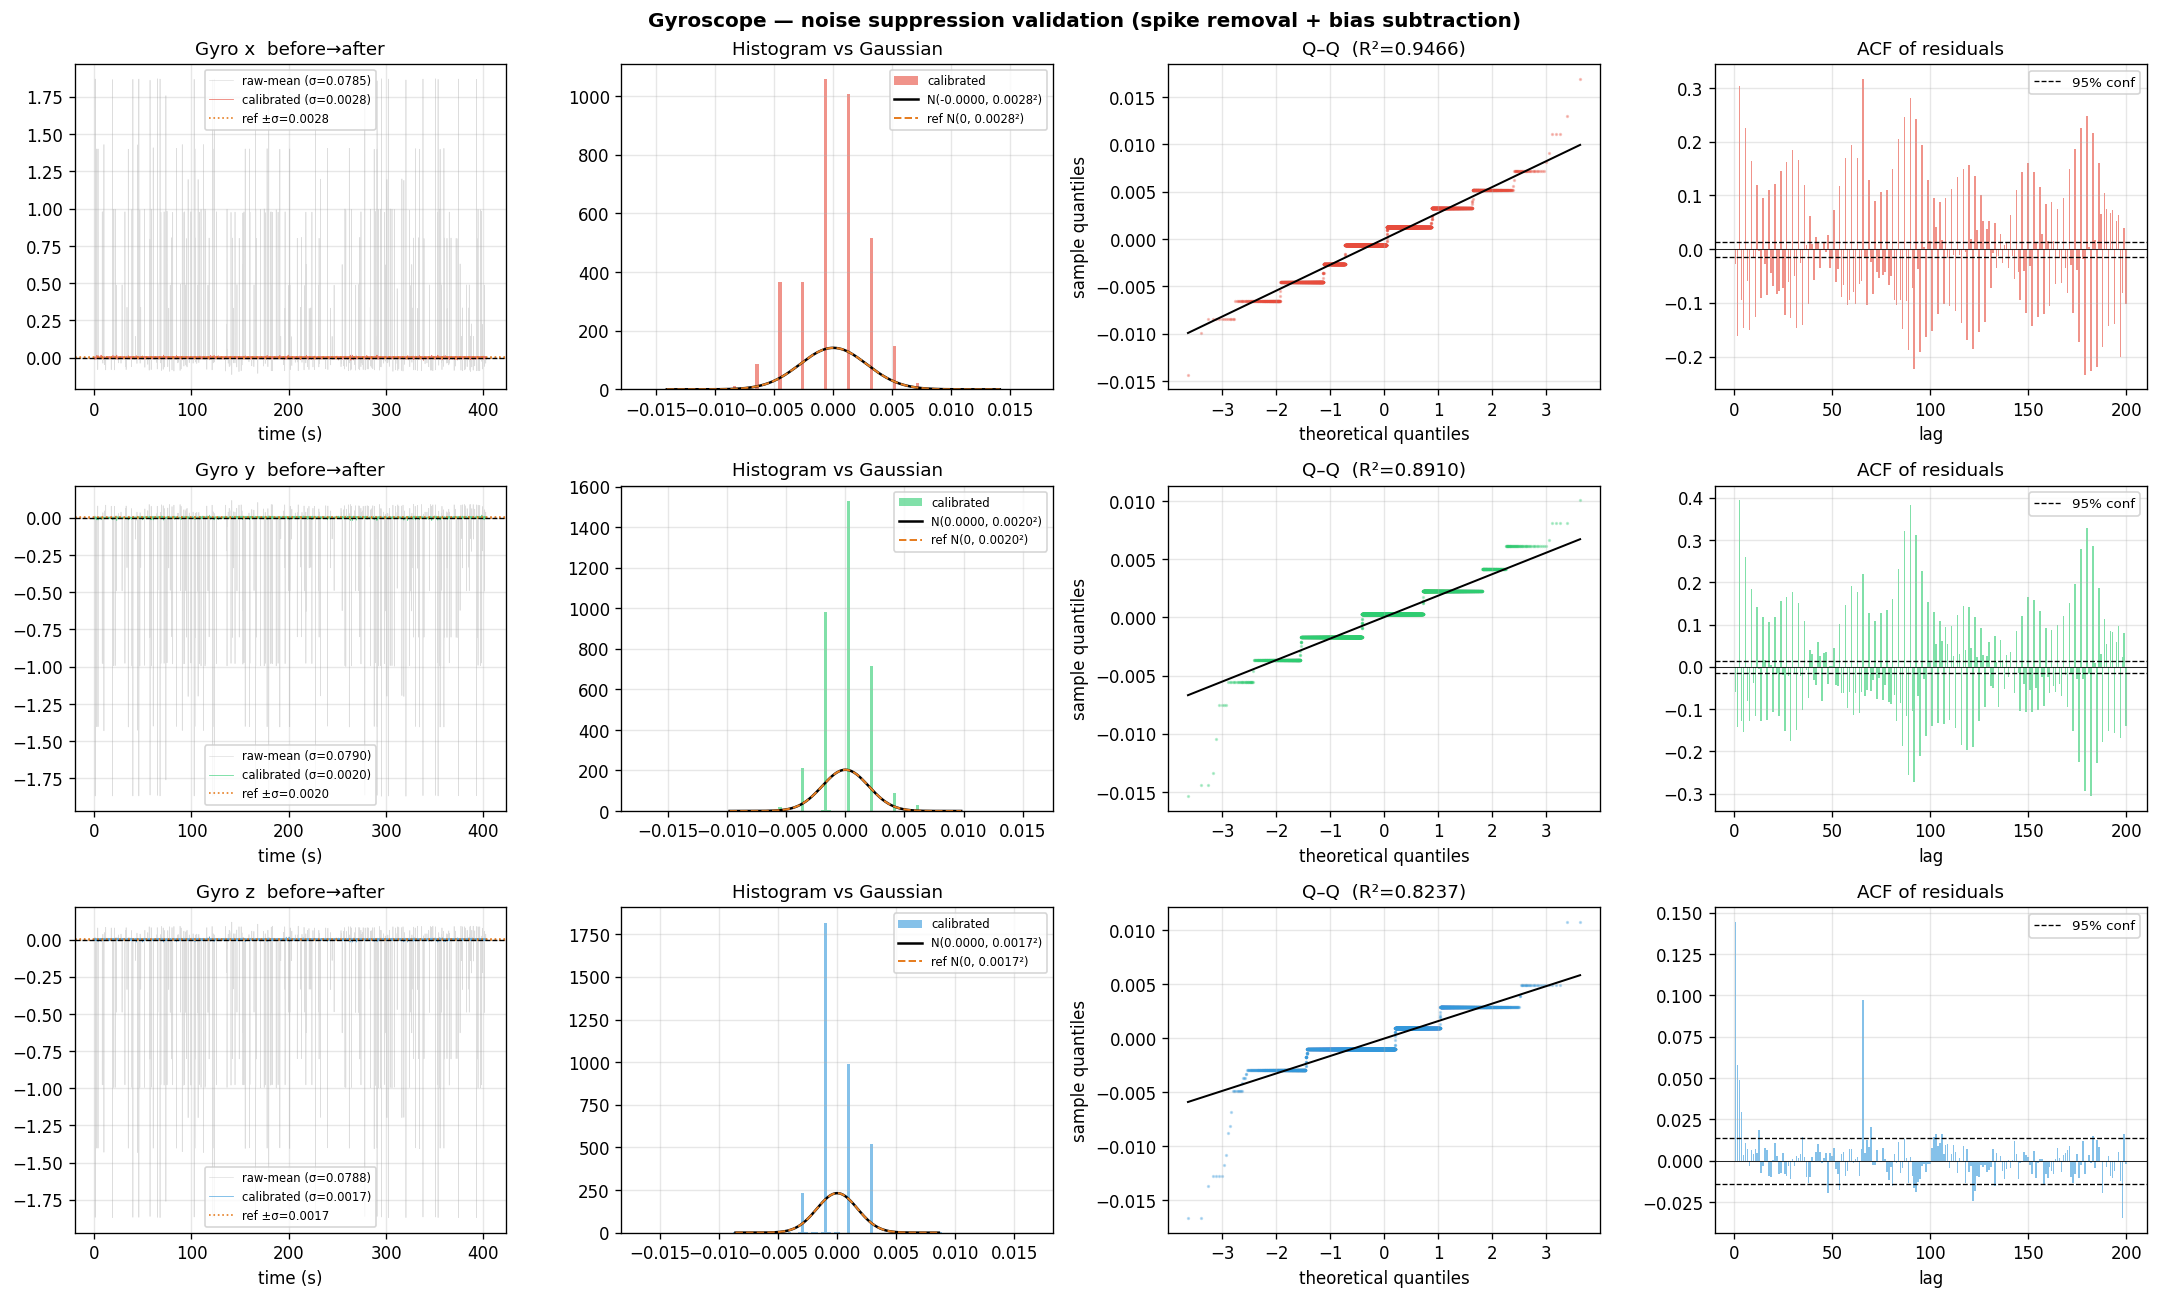


────────────────────────────────────────────────────────────────────────
  Gyroscope — noise suppression & model fit summary
────────────────────────────────────────────────────────────────────────
 Axis     σ_cal   suppress   σ/ref    Kurt  |Skew|  ACF_max    KS_p  status
    x   0.00282      27.8×    1.00    0.52   0.206   0.3029  0.0000  ⚠️  [ACF]
    y   0.00196      40.3×    1.00    3.38   0.148   0.3934  0.0000  ⚠️  [ACF, Kurt]
    z   0.00172      45.8×    1.00    4.07   0.029   0.1442  0.0000  ⚠️  [ACF, Kurt]
────────────────────────────────────────────────────────────────────────
  suppress = raw_std / calibrated_std  (how much bias was removed)
  σ/ref    = calibrated_std / RUN_008 reference σ_n  (ideal ≈ 1.0)
  ACF_max  = max|ACF| in first 20 lags  (white noise: should be < 0.10)


In [19]:
# ── 3-B  Gyroscope validation ─────────────────────────────────────────────────
print('Validating Gyroscope model...')

fig, axes_grid = plt.subplots(3, 4, figsize=(18, 11))
fig.suptitle('Gyroscope — noise suppression validation (spike removal + bias subtraction)',
             fontsize=12, fontweight='bold')

gyro_val_results = {}
for i, ax in enumerate(['x', 'y', 'z']):
    res = validate_with_reference(
        raw_series      = df_gyro[ax],
        residual_series = df_gyro[f'{ax}_clean'] - gyro_model.bias[i],
        label=f'Gyro {ax}', color=COLORS[ax],
        axes_row=axes_grid[i], fs_hz=FS_GYRO,
        ref_sigma=REF['gyro']['sigma_n'][i],
        time_s=df_gyro['time_s'],
    )
    gyro_val_results[ax] = res

plt.tight_layout()
plt.savefig('gyro_validation.png', bbox_inches='tight')
plt.show()

print_validation_summary(gyro_val_results, 'Gyroscope')

Validating Accelerometer model...


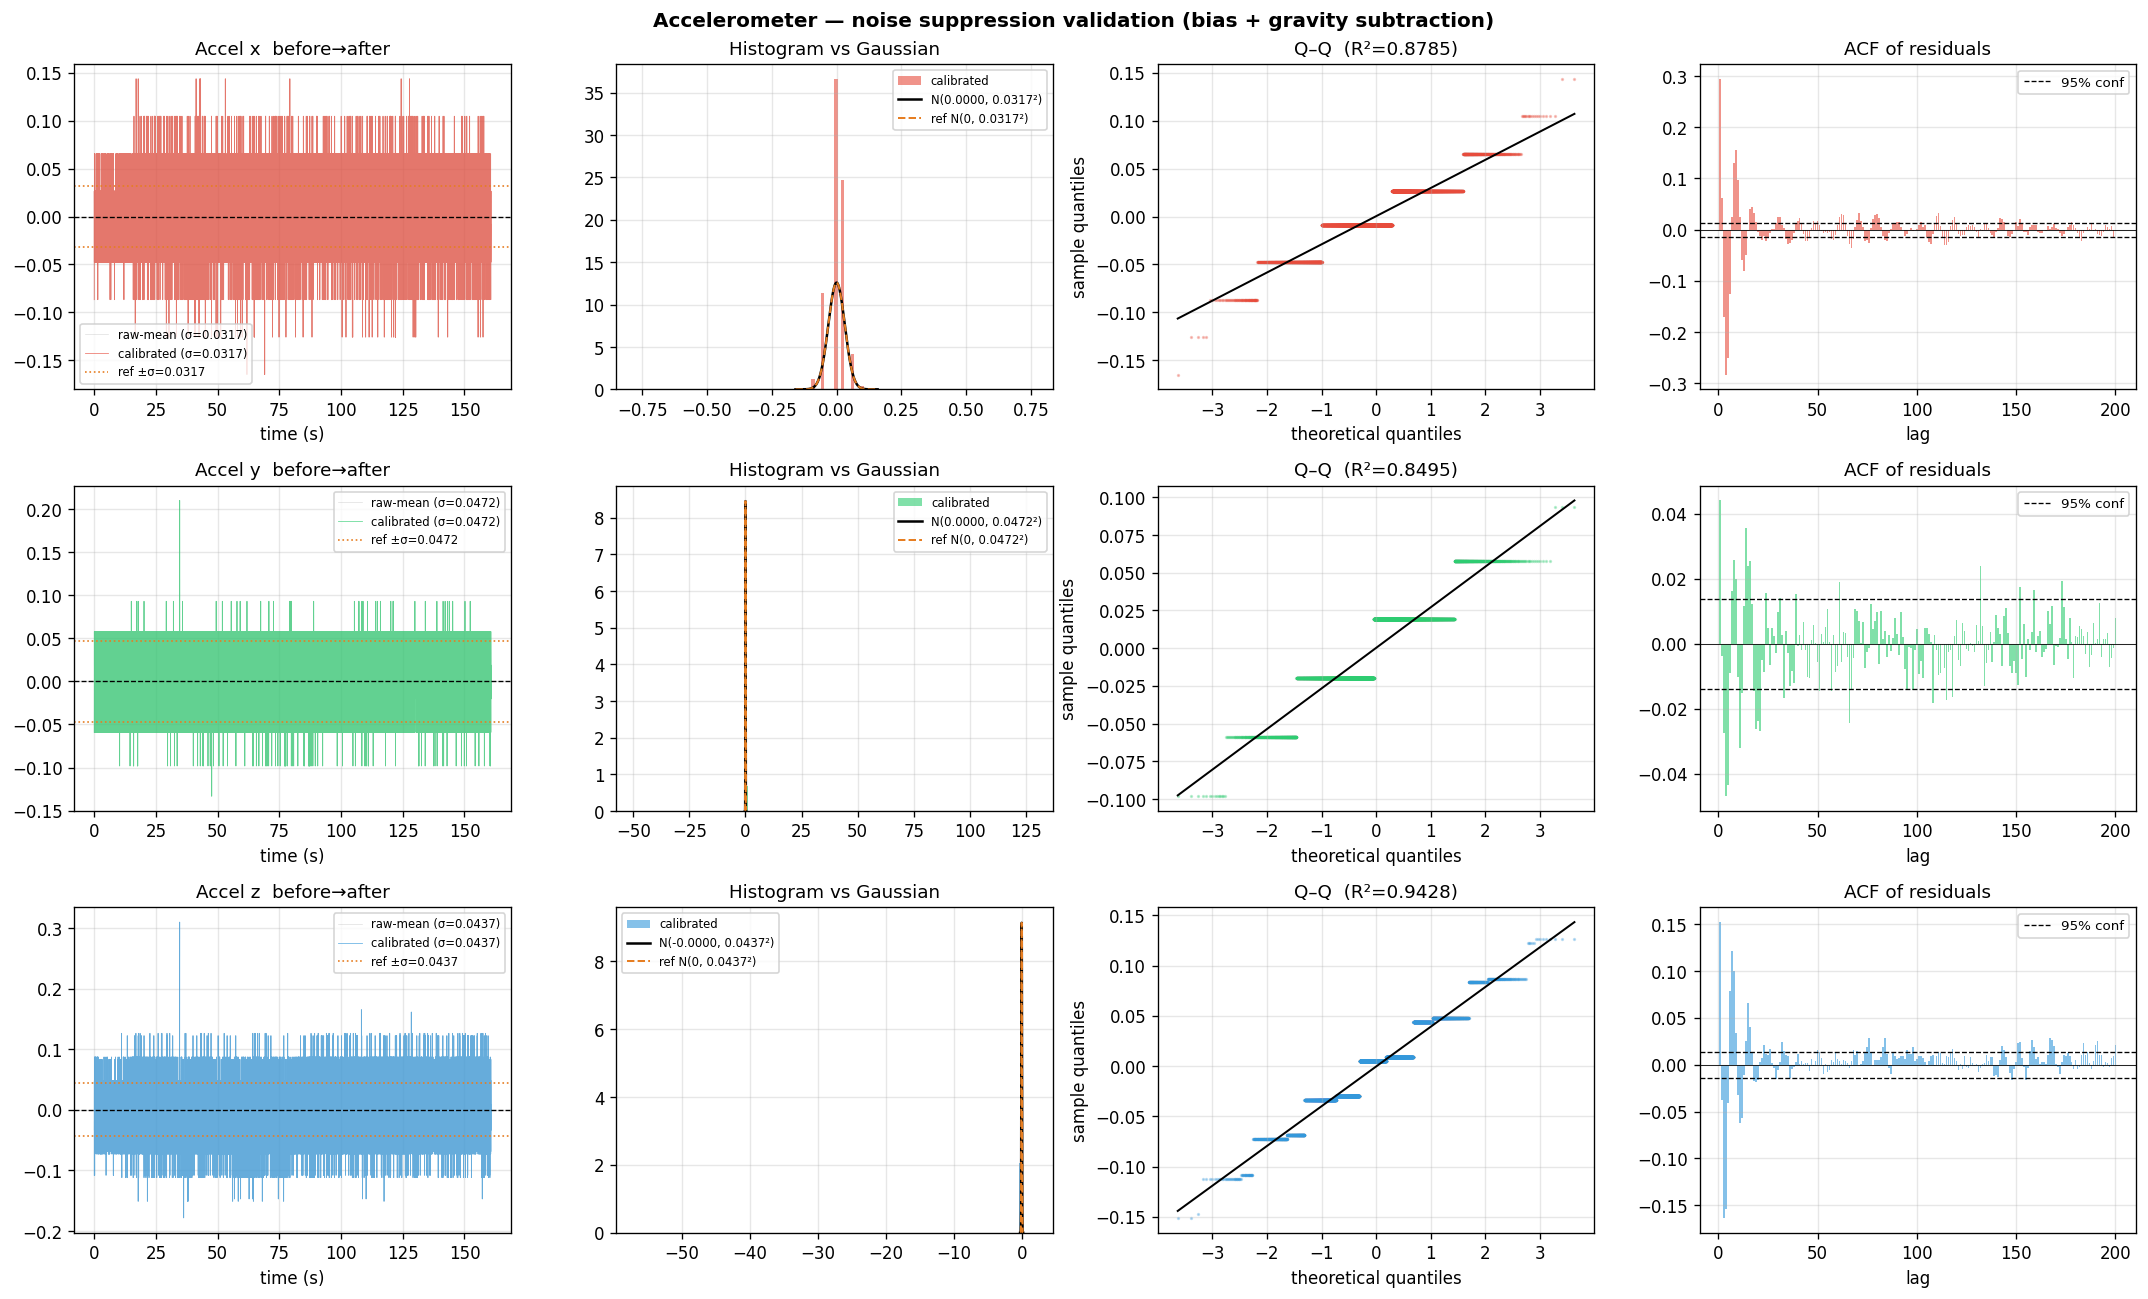


────────────────────────────────────────────────────────────────────────
  Accelerometer — noise suppression & model fit summary
────────────────────────────────────────────────────────────────────────
 Axis     σ_cal   suppress   σ/ref    Kurt  |Skew|  ACF_max    KS_p  status
    x   0.03169       1.0×    1.00    0.85   0.036   0.2945  0.0000  ⚠️  [ACF]
    y   0.04722       1.0×    1.00 4094766.69 1397.133   0.0469  0.0000  ⚠️  [Kurt, Skew]
    z   0.04367       1.0×    1.00 211980.52 163.254   0.1634  0.0000  ⚠️  [ACF, Kurt, Skew]
────────────────────────────────────────────────────────────────────────
  suppress = raw_std / calibrated_std  (how much bias was removed)
  σ/ref    = calibrated_std / RUN_008 reference σ_n  (ideal ≈ 1.0)
  ACF_max  = max|ACF| in first 20 lags  (white noise: should be < 0.10)


In [20]:
# ── 3-C  Accelerometer validation ────────────────────────────────────────────
print('Validating Accelerometer model...')

fig, axes_grid = plt.subplots(3, 4, figsize=(18, 11))
fig.suptitle('Accelerometer — noise suppression validation (bias + gravity subtraction)',
             fontsize=12, fontweight='bold')

accel_val_results = {}
for i, (raw_ax, cal_ax) in enumerate(zip('xyz', ['x_cal', 'y_cal', 'z_cal'])):
    res = validate_with_reference(
        raw_series      = df_accel[raw_ax],
        residual_series = df_accel[cal_ax],
        label=f'Accel {raw_ax}', color=COLORS[raw_ax],
        axes_row=axes_grid[i], fs_hz=FS_ACCEL,
        ref_sigma=REF['accel']['sigma_n'][i],
        time_s=df_accel['time_s'],
    )
    accel_val_results[raw_ax] = res

plt.tight_layout()
plt.savefig('accel_validation.png', bbox_inches='tight')
plt.show()

print_validation_summary(accel_val_results, 'Accelerometer')

Validating Magnetometer model...


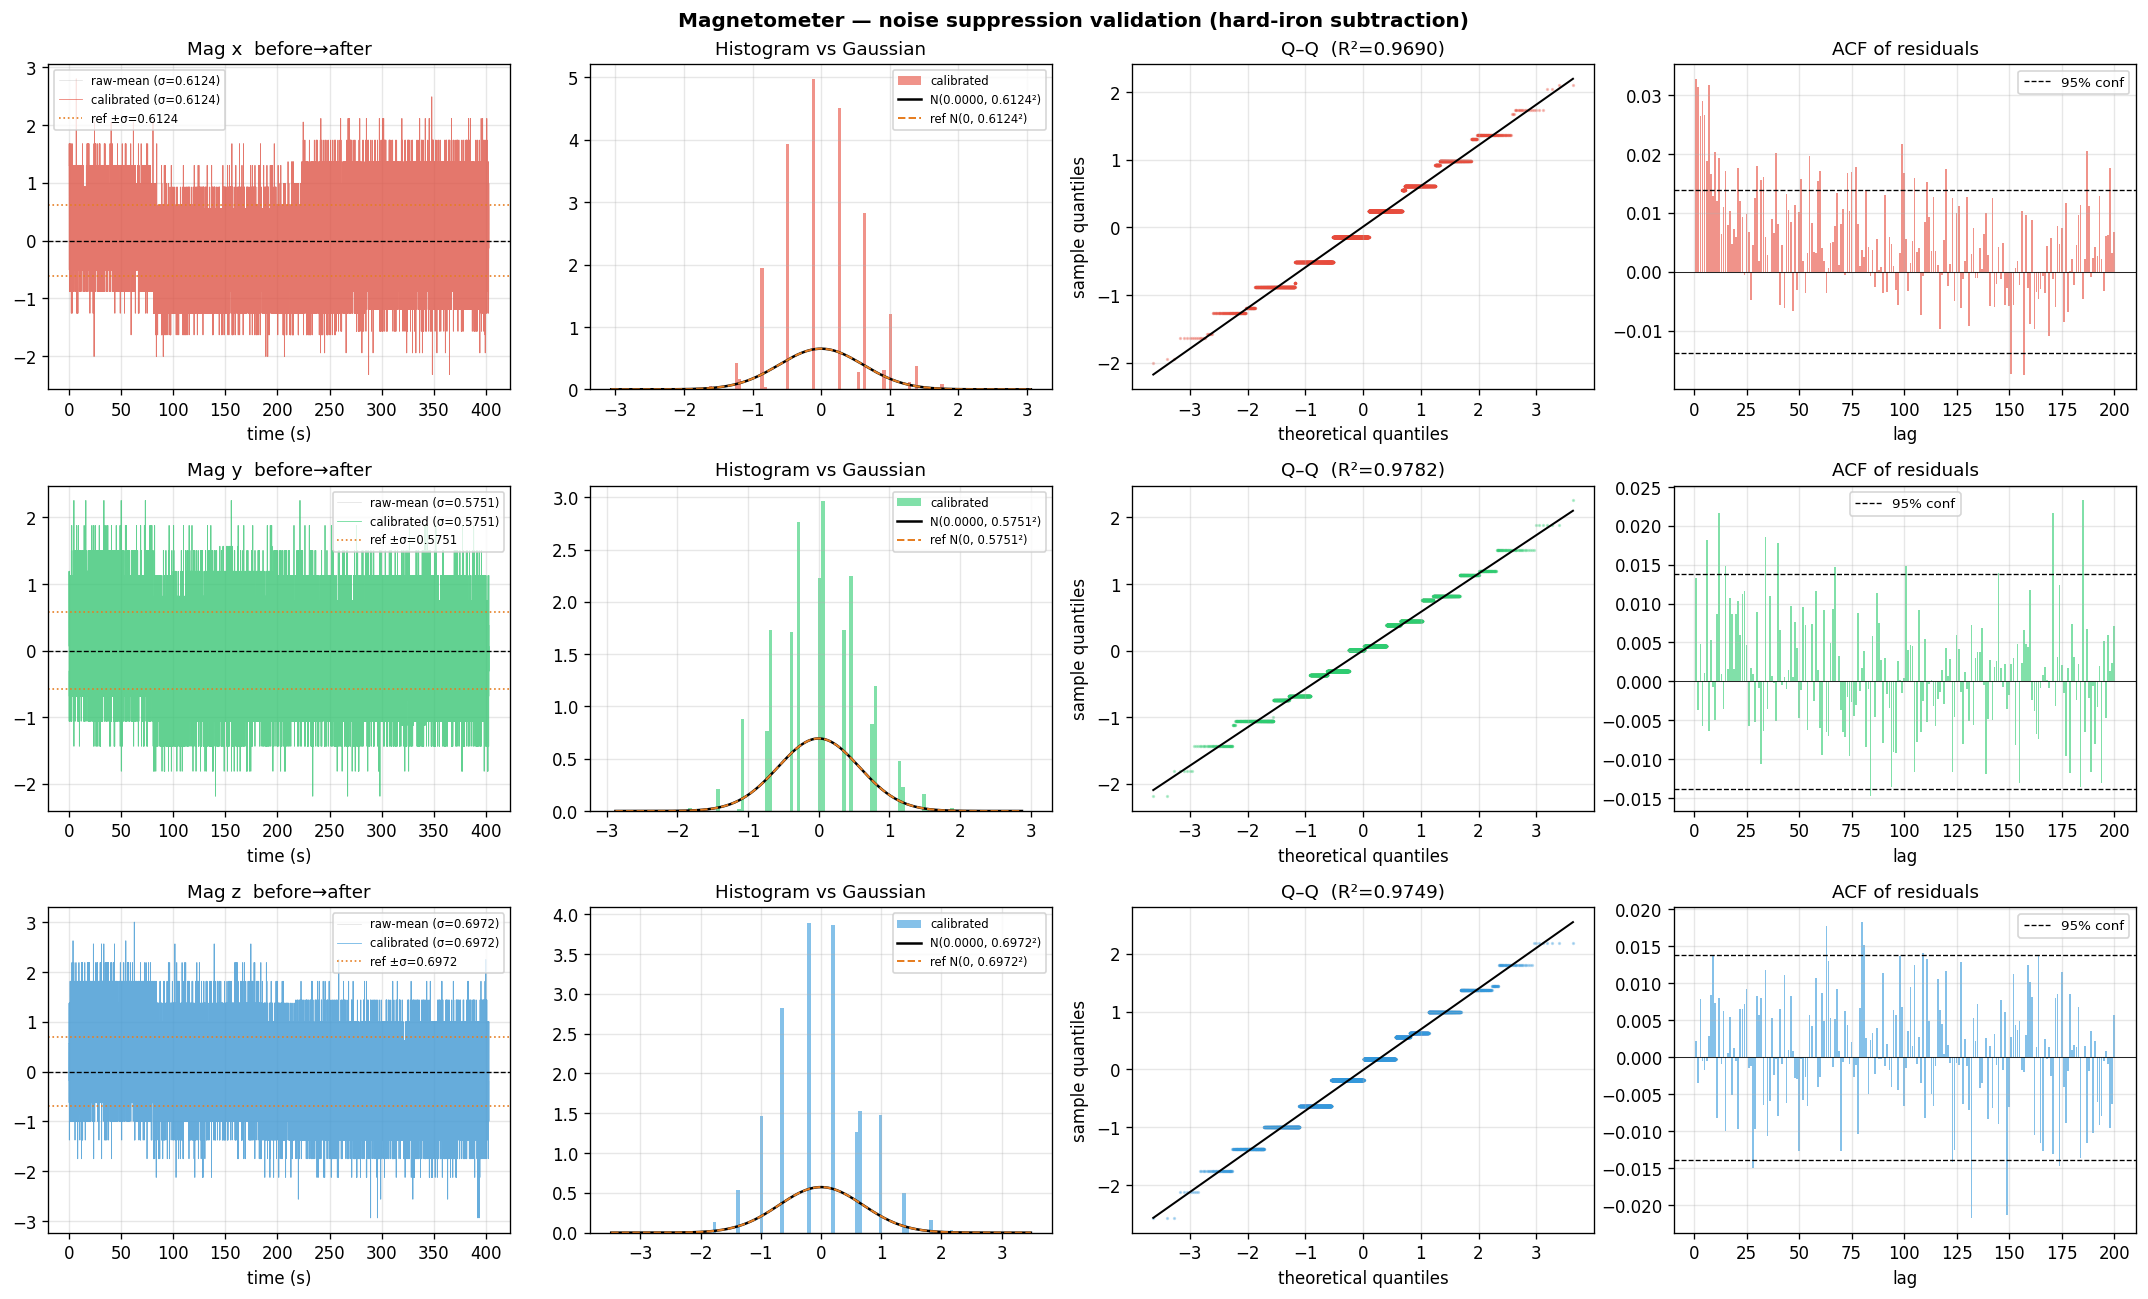


────────────────────────────────────────────────────────────────────────
  Magnetometer — noise suppression & model fit summary
────────────────────────────────────────────────────────────────────────
 Axis     σ_cal   suppress   σ/ref    Kurt  |Skew|  ACF_max    KS_p  status
    x   0.61244       1.0×    1.00   -0.21   0.111   0.0328  0.0000  ✅
    y   0.57513       1.0×    1.00   -0.03   0.060   0.0217  0.0000  ✅
    z   0.69718       1.0×    1.00   -0.10   0.047   0.0138  0.0000  ✅
────────────────────────────────────────────────────────────────────────
  suppress = raw_std / calibrated_std  (how much bias was removed)
  σ/ref    = calibrated_std / RUN_008 reference σ_n  (ideal ≈ 1.0)
  ACF_max  = max|ACF| in first 20 lags  (white noise: should be < 0.10)

Note: Mag Z axis (CV=33.6%) ⚠️ flags are expected — this is a documented
      low-SNR axis, not a sensor fault.


In [21]:
# ── 3-D  Magnetometer validation ─────────────────────────────────────────────
print('Validating Magnetometer model...')

fig, axes_grid = plt.subplots(3, 4, figsize=(18, 11))
fig.suptitle('Magnetometer — noise suppression validation (hard-iron subtraction)',
             fontsize=12, fontweight='bold')

mag_val_results = {}
for i, ax in enumerate(['x', 'y', 'z']):
    res = validate_with_reference(
        raw_series      = df_mag[ax],
        residual_series = df_mag[f'{ax}_cal'],
        label=f'Mag {ax}', color=COLORS[ax],
        axes_row=axes_grid[i], fs_hz=FS_MAG,
        ref_sigma=REF['mag']['sigma_n'][i],
        time_s=df_mag['time_s'],
    )
    mag_val_results[ax] = res

plt.tight_layout()
plt.savefig('mag_validation.png', bbox_inches='tight')
plt.show()

print_validation_summary(mag_val_results, 'Magnetometer')
print()
print('Note: Mag Z axis (CV=33.6%) ⚠️ flags are expected — this is a documented')
print('      low-SNR axis, not a sensor fault.')

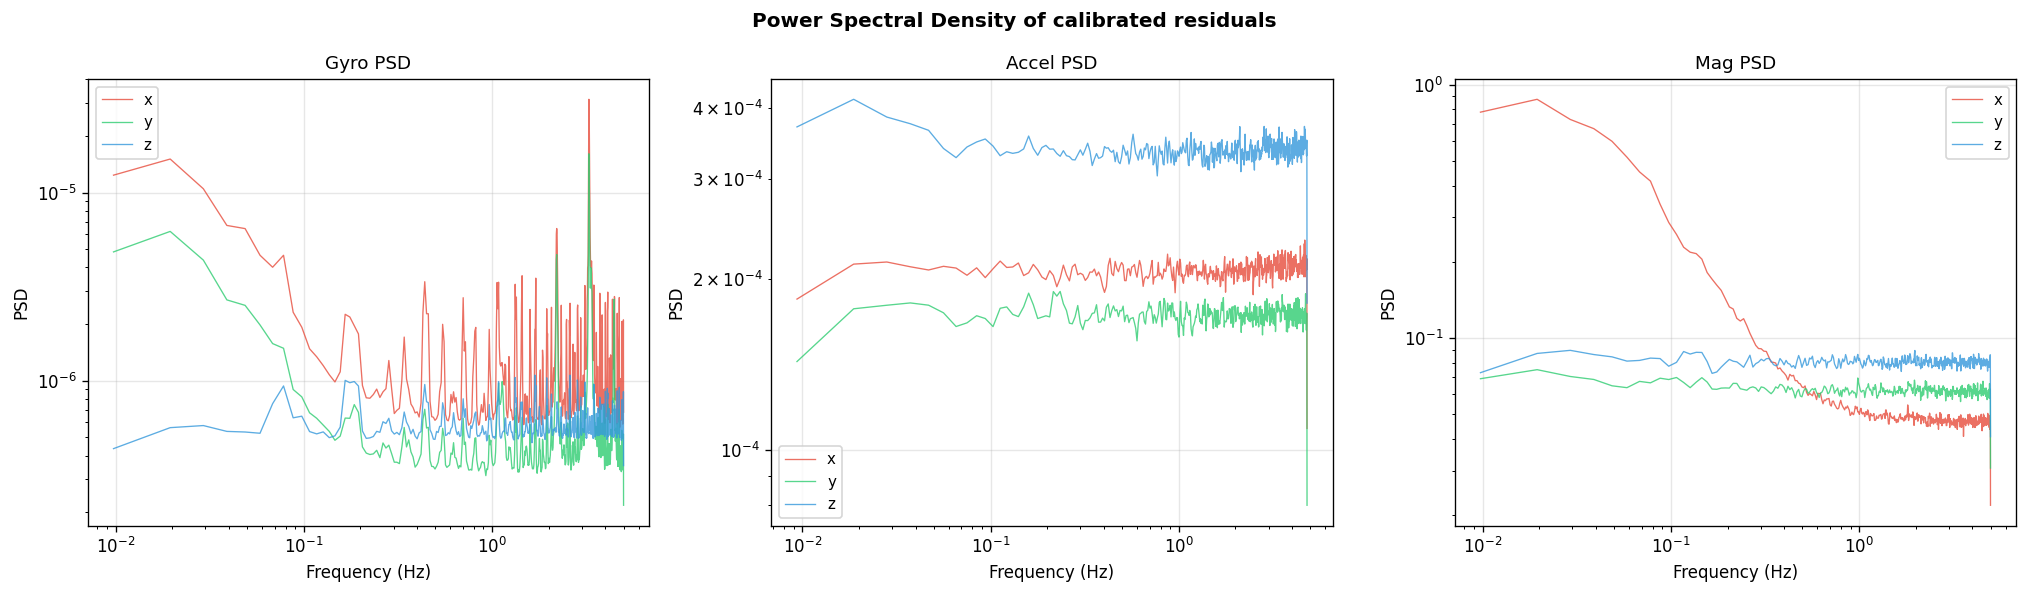

Flat PSD → white noise model appropriate.
Rising PSD at low freq → coloured noise / drift → may need higher-order model.


In [22]:
# ── 3-E  PSD check: verify -10 dB/decade slope (white noise signature) ────────
#   White noise has a flat power spectral density.
#   If the PSD slopes downward before a rolloff it means a coloured-noise component
#   (e.g. flicker noise, temperature drift) is present.

fig, axes_p = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Power Spectral Density of calibrated residuals',
             fontsize=12, fontweight='bold')

psd_data = [
    ('Gyro',  df_gyro,  ['x_clean','y_clean','z_clean'], FS_GYRO,  [gyro_model.bias[i] for i in range(3)]),
    ('Accel', df_accel, ['x_cal',  'y_cal',  'z_cal'  ], FS_ACCEL, [0,0,0]),
    ('Mag',   df_mag,   ['x_cal',  'y_cal',  'z_cal'  ], FS_MAG,   [0,0,0]),
]

for ax_idx, (name, df, cols, fs, biases) in enumerate(psd_data):
    for j, (col, color) in enumerate(zip(cols, COLORS.values())):
        sig = df[col].dropna().values - biases[j]
        # Welch PSD on downsampled signal for speed
        if len(sig) > 500_000:
            sig = sig[::len(sig)//500_000]
            fs_eff = fs / (len(df[col]) // 500_000)
        else:
            fs_eff = fs
        f, pxx = signal.welch(sig, fs=fs_eff, nperseg=1024)
        axes_p[ax_idx].loglog(f[1:], pxx[1:], color=color,
                              alpha=0.8, lw=0.8, label=col.split('_')[0])
    axes_p[ax_idx].set_title(f'{name} PSD')
    axes_p[ax_idx].set_xlabel('Frequency (Hz)')
    axes_p[ax_idx].set_ylabel('PSD')
    axes_p[ax_idx].legend(fontsize=9)

plt.tight_layout()
plt.savefig('psd_check.png', bbox_inches='tight')
plt.show()

print('Flat PSD → white noise model appropriate.')
print('Rising PSD at low freq → coloured noise / drift → may need higher-order model.')

In [24]:
# ── 3-F  RUN_009 reference parameter summary ──────────────────────────────────

print('=' * 65)
print('  RUN_009 — sensor noise reference (σ_n per axis)')
print('=' * 65)

print('\n--- GYRO ---')
for i, ax in enumerate('xyz'):
    print(f'  {ax}: bias={gyro_model.bias[i]:+.6f} rad/s   σ_n={gyro_model.sigma_n[i]:.6f} rad/s')

print('\n--- ACCEL ---')
for i, ax in enumerate('xyz'):
    print(f'  {ax}: bias={accel_model.bias[i]:+.6f} m/s²   σ_n={accel_model.sigma_n[i]:.6f} m/s²')

print('\n--- MAG ---')
for i, ax in enumerate('xyz'):
    print(f'  {ax}: hard_iron={mag_model.hard_iron[i]:+.4f} µT   σ_n={mag_model.sigma_n[i]:.4f} µT')

print('\n  These σ_n values are the cross-run validation reference.')
print('  A new run is flagged ⚠️  if its calibrated σ falls outside')
print(f'  [{THRESH["sigma_ratio"][0]}×, {THRESH["sigma_ratio"][1]}×] of these reference values.')
print('=' * 65)

  RUN_009 — sensor noise reference (σ_n per axis)

--- GYRO ---
  x: bias=+0.002608 rad/s   σ_n=0.002820 rad/s
  y: bias=-0.004181 rad/s   σ_n=0.001961 rad/s
  z: bias=-0.000971 rad/s   σ_n=0.001722 rad/s

--- ACCEL ---
  x: bias=+0.469558 m/s²   σ_n=0.031690 m/s²
  y: bias=-0.171329 m/s²   σ_n=0.047220 m/s²
  z: bias=-0.049560 m/s²   σ_n=0.043673 m/s²

--- MAG ---
  x: hard_iron=+18.9472 µT   σ_n=0.6124 µT
  y: hard_iron=-17.0021 µT   σ_n=0.5751 µT
  z: hard_iron=+1.3757 µT   σ_n=0.6972 µT

  These σ_n values are the cross-run validation reference.
  A new run is flagged ⚠️  if its calibrated σ falls outside
  [0.5×, 2.0×] of these reference values.


---
## What to do next based on validation results

| Observation | Diagnosis | Action |
|---|---|---|
| Gyro kurtosis >> 3 even after medfilt | Spikes not fully removed | Increase `kernel_size` to 7 or 9; or use IQR-based clipping |
| Gyro ACF[1] >> 0.05 | Residual is coloured — bias drifts slowly | Add a Gauss-Markov bias state with time constant τ★ (once Allan minimum found) |
| Accel Z ACF shows periodicity | Periodic environmental vibration | Apply a notch filter at the offending frequency before modelling |
| Mag Z non-Gaussian / high kurtosis | Expected (CV=33.6%) | Keep Z-axis R inflated; consider excluding from heading fusion entirely |
| Any PSD rising at low freq | Drift not captured by random-walk model | Add a first-order Gauss-Markov process with correlation time = 1/f_knee |

**When to re-run Allan for gyro BI:**  
Collect a new static dataset of at least 6–8 hours under stable temperature, then re-run the Allan cell from your original notebook. The minimum should appear around τ ≈ 10⁴–10⁵ s based on the current downward trend.